Make a diagram that explains $\bar M_{\rm{UV}}$ \& $\sigma_{\rm{UV}}$

In [523]:
from escripts import eMCMC
from escripts import eplots
from escripts import edata
from matplotlib.gridspec import GridSpec
import zeus21
import scipy
from matplotlib.collections import LineCollection
import math

In [5]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt'
               , '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
params = eMCMC.build_param_data({})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [331]:
std_params = [1, -0.04, -1.15, 0.05, 11.5, -0.05, -1.42, -0.1, 0.58, 0.1, -0.5, 0.6]

In [533]:
def PMUV(my_UVLF, param_values, Mhtab = None, zs = None, z_errs = None, MUVcenters = None, MUVwidths = None, ncols = 3, logscale = False):
    """
    Plot P(MUV|Mh) for two different redshifts given a set of UVLF parameters
    Inputs:
        my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
        param_values [1darray]: values of parameters to calculate MUV from Mh
        Mhtab [1darray]: log(Mh/M_odot) for plotting
        zs [1darray]: redshfits to plot (as separate subplots on a grid)
        z_errs [1darray]: redshift uncertainty (if None will default to 0.5)
        MUVcenters [1darray]: centers of MUV bins to plot
        MUVwidths [1darray]: widhts of MUV bins to plot. Defaults to 0.5 if none given
        ncols [int]: number of columns to plot the redshift bins over
        logscale [bool]: whether or not to use log scale for the y axis
    Outputs:
        fig, ax: Figure showing P(MUV|Mh) for different halo masses. Note that even without time-evolving parameters, the P(MUV|Mh) will look different at
        differnet redshifts due time-evolving mass accretion rates
    """

    if Mhtab is None:
        Mhtab = np.arange(9, 13.75, 0.75)

    if zs is None:
        zs = my_UVLF.zs
        z_errs = [dat[1] for dat in my_UVLF.data]
    if z_errs is None:
        z_errs = np.full_like(zs, 0.5, dtype = float)

    nz = len(zs)
    fig = plt.figure()
    gs = GridSpec(math.ceil(nz / ncols), ncols, figure=fig)
    plt.subplots_adjust(hspace = 0.3, wspace = 0)

    Mhtab_og = my_UVLF.HMFintclass.Mhtab # Save this to reset it later. There's probably a more elegant solution I could come up with at another time
    my_UVLF.HMFintclass.Mhtab = 10**Mhtab # Set the UVLF table of halo masses to the input value

    if MUVcenters is None: 
        # Get unique x values and their corresponding errors
        MUVcenters_lowres, MUVwidths_lowres = my_UVLF.get_all_MUV_bins() # Get coarse MUV binning
        MUVcenters, MUVwidths = np.linspace(MUVcenters_lowres.min(), MUVcenters_lowres.max(), 1000), np.full(1000, 0.5)
    elif MUVwidths is None:
        MUVwidths = np.full_like(MUVcenters, 0.5)

    if len(Mhtab) > 1:
        # Create gradient for color-coding curves based on corresponding halo mass
        cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], Mhtab)
    
    axs = []
    all_weights = []
    for i, (z, z_err) in enumerate(zip(zs, z_errs)): # Plot curves for each redshift
        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)
        weights = my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths, param_values, return_weights = True)

        for i, Mh in enumerate(Mhtab): # Plot different color-coded Gaussians for different halo masses
            if len(Mhtab) > 1:
                # Get color based on halo mass
                frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min()) 
                color = cmap(frac)
            else:
                color = periwinkle
            ax.plot(MUVcenters, weights[i], color = color, ls = 'solid')
            all_weights.append(weights[i])
        ax.set_title(fr'${round(z-z_err, 1)} \lesssim z \lesssim {round(z+z_err, 1)}$', fontsize = 20, pad = 8)
        ax.invert_xaxis()
        if logscale:
            ax.set_yscale('log')

    all_weights = np.concatenate(all_weights)

    # Color bar things:
    if len(Mhtab)>1:
        cbar = fig.colorbar(sm, ax = axs, boundaries=boundaries, ticks=Mhtab, aspect = 7*math.ceil(nz/ncols))
        cbar.set_label(r'$\log_{10}{M_h}$')

        


    xlabel = r'$M_{\rm{UV}}$ [mag]'
    ylabel = r'$p(M_{\rm{UV}}|M_h)$'
    eplots.multicol(gs, axs, ylims = (0.9*all_weights.min(), 1.1*all_weights.max()))

    my_UVLF.HMFintclass.Mhtab = Mhtab_og # Reset the Mhtab

    return fig, axs, cmap, sm

(-16.0, -22.0)

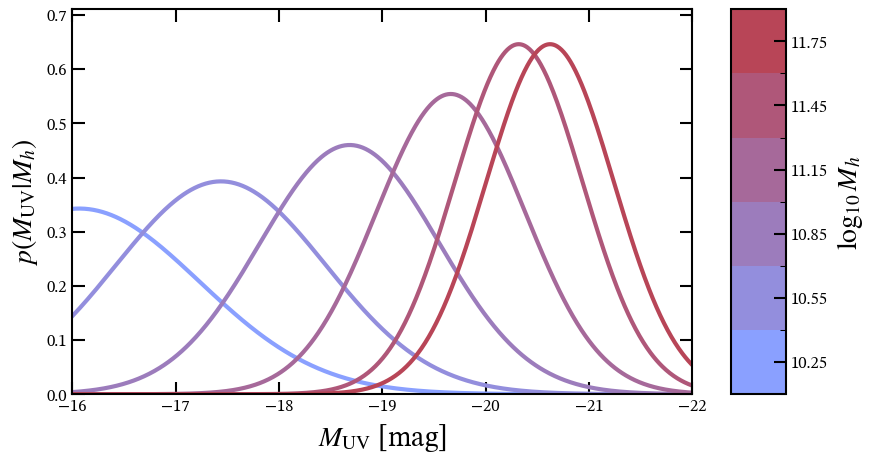

In [534]:
PMh, ax, cmap, sm = PMUV(my_UVLF, std_params, zs = [10], ncols = 1, Mhtab = np.linspace(10.25, 11.75, 6))
PMh.set_size_inches(10,5)
ax[0].set_title('')
ax[0].set_xlabel(r'$M_{\rm{UV}}$ [mag]')
ax[0].set_ylabel(r'$p(M_{\rm{UV}}|M_h)$')
ax[0].set_xlim(-16, -22)

In [574]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

def make_smooth_cmap_from_piecewise(sm, n_colors=256):
    """
    Take a ScalarMappable `sm` (piecewise colormap) and return a smooth LinearSegmentedColormap
    with the same normalization.
    
    Parameters
    ----------
    sm : ScalarMappable
        Your existing ScalarMappable with piecewise colormap and normalization.
    n_colors : int
        Number of discrete levels to interpolate for smoothness.
    
    Returns
    -------
    smooth_cmap : LinearSegmentedColormap
        Smooth colormap.
    new_sm : ScalarMappable
        New ScalarMappable with same normalization.
    """
    # Sample colors from the original piecewise cmap
    colors = sm.cmap(np.linspace(0, 1, n_colors))
    smooth_cmap = LinearSegmentedColormap.from_list("smooth_custom", colors)
    
    # Create a new ScalarMappable using the same normalization
    new_sm = ScalarMappable(cmap=smooth_cmap, norm=sm.norm)
    
    return smooth_cmap, new_sm

In [577]:
# Create a smooth colormap
cmap = LinearSegmentedColormap.from_list("smooth_gradient", [eplots.periwinkle, eplots.red])

# Normalization for mapping values to colormap
norm = Normalize(vmin=10.25, vmax=11.75)

# Create a ScalarMappable for the colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # necessary for colorbar

In [661]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.optimize

def f(x, a, b):
    return 10**((a*x)+b)

def sfe_shape_diff_z(my_UVLF, param_values, Mhtab, z, cmap, sm, n_fine=2000):
    """
    Plot SFE vs log(Mh) with a smooth gradient using scatter points.
    `n_fine` controls the number of interpolated points for smoothness.
    """
    fig = plt.figure(figsize=(6, 3))
    ax_rect  = [0.10, 0.12, 0.78, 0.80]
    ax = fig.add_axes(ax_rect)
    
    # Compute SFE
    params = my_UVLF.time_evolution(param_values, z)
    Astro_Parameters = my_UVLF.param_wrapper(params)
    SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
        Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab
    )
    
    # Mark maxima
    max_idx = np.argmax(SFEs)
    ax.axvline(Mhtab[max_idx], color=eplots.navy, lw=2, ls='dashed')
    ax.axhline(SFEs[max_idx]+0.0002, color=eplots.navy, lw=2, ls='dashed')
    
    # Interpolate to finer grid for smooth scatter
    interp_func = interp1d(Mhtab, SFEs, kind='cubic')
    Mhtab_fine = np.linspace(Mhtab.min(), Mhtab.max(), n_fine)
    SFEs_fine = interp_func(Mhtab_fine)
    
    # Plot gradient line as scatter
    scatter = ax.scatter(
        Mhtab_fine, SFEs_fine, c=Mhtab_fine, cmap=sm.cmap, norm=sm.norm, s=20, edgecolors='none'
    )
    
    # Low-mass and high-mass fits (dashed)
    lm_fit, _ = scipy.optimize.curve_fit(f, Mhtab[10:50], SFEs[10:50])
    a, b = lm_fit
    ax.plot(Mhtab[10:50], f(Mhtab[10:50], a+0.004, b), lw=2, ls='dashed', color=eplots.navy)

    hm_fit, _ = scipy.optimize.curve_fit(f, Mhtab[175:], SFEs[175:])
    a, b = hm_fit
    ax.plot(Mhtab[180:], f(Mhtab[180:], a+0.003, b), lw=2, ls='dashed', color=eplots.navy)
    
    # Labels and log scale
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$f_{\star} = \dot M_\star / \dot M_{\rm{gas}}$')
    ax.set_yscale('log')
    
    return fig, ax

Text(11.32, 0.027, '$\\mathbf{M_c}$')

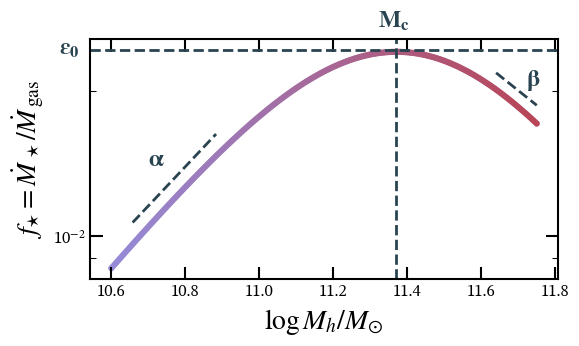

In [662]:
sfe, ax = sfe_shape_diff_z(my_UVLF, std_params, Mhtab = np.linspace(10.6, 11.75, 200), z=10, cmap = cmap, sm = sm, n_fine = 250)

ax.text(10.46, 2.38e-2, r'$\mathbf{\epsilon_{0}}$', color = eplots.navy)
ax.text(10.7, 1.4e-2, r'$\mathbf{\alpha}$', color = eplots.navy)
ax.text(11.72, 2.05e-2, r'$\mathbf{\beta}$', color = eplots.navy)
ax.text(11.32, 2.7e-2, r'$\mathbf{M_c}$', color = eplots.navy)

In [663]:
sfe.savefig('/Users/eb35267/Desktop/figures/Qual_26/Final/Diagram/sfe.png', dpi = 300)

In [349]:
importlib.reload(eplots)

/Users/eb35267/Desktop/code/home/escripts/eplots.py:657: SyntaxWarning: invalid escape sequence '\s'
  PMh = hmf*Mhtab*np.log(10)/ np.trapz(hmf*Mhtab*np.log(10), np.log10(Mhtab)) # Looks weird because it's an integral over logMh. See notes from 2/9 where I derive this


<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [367]:
PMh.savefig('/Users/eb35267/Desktop/figures/Qual_26/Final/Diagram/PMUV.png', dpi = 300)

In [428]:
importlib.reload(eplots)

/Users/eb35267/Desktop/code/home/escripts/eplots.py:658: SyntaxWarning: invalid escape sequence '\s'
  


<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

In [443]:
std_params

[1, -0.04, -1.15, 0.05, 11.5, -0.05, -1.42, -0.1, 0.58, 0.1, -0.5, 0.6]

In [450]:
0.2 + 0.58 + (-0.5*(10.8-11))

0.8799999999999997

In [650]:
def sigma_Mh(my_UVLF, param_values, zs = None, plot_Gelli = True):
    """
    Plot the relationship between sigma & Mh over different redshifts
    Inputs:
        my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
        param_values [1darray]: values of parameters to calculate SFE
        zs [1darray]: redshifts to plot
        plot_Gelli [bool]: whether or not to plot the Gelli+24 line for comparison
    Returns:
        fig: A figure showing the relationship between sigma_UV & Mh at different redshifts, compared to the parameterization used in Gelli+24
    """
    
    fig = plt.figure(figsize=(5, 3))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # narrow right slot for cbar
    ax = fig.add_axes(ax_rect)

    if zs is None:
        zs = np.arange(4, 16, 2)

    Mhtab_og = my_UVLF.HMFintclass.Mhtab # Save this to reset it later. There's probably a more elegant solution I could come up with at another time
    my_UVLF.HMFintclass.Mhtab = 10**np.linspace(8.5, 12, 100) # Set the UVLF table of halo masses to the input value


    sig_array = my_UVLF.time_evolution(param_values, zs[0])[-1]
    color = eplots.yellow
    ax.plot(Mhtab, sig_array, ls = '-', color = color)


    if plot_Gelli: # Compare to the Gelli+24 parameterization
        sig_gelli = (-0.34 * Mhtab) + 4.5
        ax.plot(Mhtab, sig_gelli, linestyle = '--', color = red, label = 'Gelli+24')
        ax.legend()

    # Plot min(sig)
    min_sig = param_values[-1]
    # ax.axhline(min_sig, zorder = 0, ls = 'dotted', color = 'black', lw = 1)
    #ax.text(9.5, min_sig + 0.03, r'$\min(\sigma_{\rm{UV}})=$' + f' {round(min_sig, 2)}', size = 15, ha = 'center')
    ax.axhline(min_sig, zorder = 0, ls = 'dotted', color = eplots.navy, lw = 1)

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$\sigma_{\rm{UV}}$')

    # Set Mhtab back
    my_UVLF.HMFintclass.Mhtab = Mhtab_og
    
    return fig, ax

In [657]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def sigma_Mh(my_UVLF, param_values, cmap, sm, zs=None, n_fine=250):
    """
    Plot sigma_UV vs Mh with a smooth gradient along halo mass using scatter points.
    cmap: colormap
    sm: ScalarMappable with the correct normalization
    """
    fig = plt.figure(figsize=(5, 3))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # main axes
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # colorbar axes
    ax = fig.add_axes(ax_rect)

    if zs is None:
        zs = np.arange(4, 16, 2)  # will just pick first if multiple redshifts

    Mhtab_og = my_UVLF.HMFintclass.Mhtab # Save this to reset it later. There's probably a more elegant solution I could come up with at another time
    my_UVLF.HMFintclass.Mhtab = 10**np.linspace(10.25, 11.75, 100) # Set the UVLF table of halo masses to the input value

    # Use the first redshift only (or zs[0])
    z = zs[0]
    sig_array = my_UVLF.time_evolution(param_values, z)[-1]

    # Interpolate for smooth gradient
    Mhtab = np.log10(my_UVLF.HMFintclass.Mhtab)
    interp_func = interp1d(Mhtab, sig_array, kind='linear')
    Mhtab_fine = np.linspace(Mhtab.min(), Mhtab.max(), n_fine)
    sig_fine = interp_func(Mhtab_fine)

    # Scatter plot with color mapped to halo mass
    ax.scatter(Mhtab_fine, sig_fine, c=Mhtab_fine, cmap=cmap, norm=sm.norm,
               s=20, edgecolors='none')

    # Plot min(sig)
    min_sig = param_values[-1]
    ax.axhline(min_sig, zorder=0, ls='dotted', color=eplots.navy, lw=1)

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$\sigma_{\rm{UV}}$')

        # Set Mhtab back
    my_UVLF.HMFintclass.Mhtab = Mhtab_og

    return fig, ax

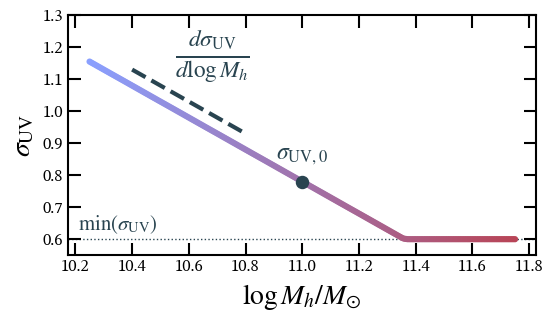

In [659]:
sig_fig, ax = sigma_Mh(my_UVLF, std_params, cmap, sm, zs = [10])
ax.set_ylim(0.55, 1.3)
ax.scatter(11, 0.78, zorder = 2, s = 75, color = eplots.navy)
ax.plot([10.4, 10.8], [1.13, 0.93], ls = 'dashed', color = eplots.navy)
ax.text(10.55, 1.15, r'$\frac{d\sigma_{\rm{UV}}}{d\log M_h}$', color = eplots.navy, fontsize = 24)
ax.text(11, 0.85, r'$\sigma_{\rm{UV}, 0}$', ha = 'center', color = eplots.navy)
ax.text(10.35, 0.6 + 0.03, r'$\min(\sigma_{\rm{UV}})$', size = 15, ha = 'center', color = eplots.navy)
sig_fig.set_size_inches(6, 3)

In [660]:
sig_fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/final/Diagram/sig.png', dpi = 300)

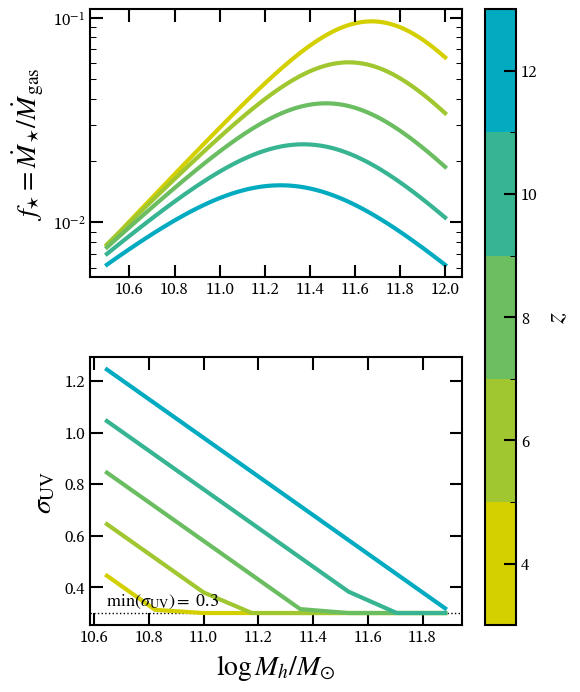

In [201]:
# def sfe_shape_diff_z(my_UVLF, param_values, ax, cmap, zs = None, Mhtab = None, id_max = False):
#     """
#     Plot SFE vs. halo mass at different redshifts
#     Inputs:
#         my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
#                                         right format for zeus21
#         param_values [1darray]: values of parameters to calculate SFE
#         zs [1darray]: redshifts to plot
#         Mhtab [1darray]: log10(Mh) to plot over
#         id_max [bool]: Whether or not to identify the maximum SFE at the highest and lowest redshift bin
#     Returns:
#         fig: A figure showing the SFE over the range of given halo masses & redshifts
#     """

#     if zs is None:
#         zs = np.arange(4, 16, 2)

#     if Mhtab is None: 
#         Mhtab = np.linspace(9, 13, 200)
    
#     for z in zs:
#         # Calculate parameters at this z
#         params = my_UVLF.time_evolution(param_values, z)
#         Astro_Parameters = my_UVLF.param_wrapper(params)
#         # Calculate SFE
#         SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
#             Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab)
#         # Assign color
#         if len(zs) > 1:
#             frac = (z - min(zs)) / (max(zs) - min(zs))
#             color = cmap(frac)
#         else:
#             color = yellow
#         # Plot
#         plt.plot(Mhtab, SFEs, color = color, ls = '-', zorder = 0)

#         if ((z == max(zs) or z==min(zs)) and id_max): # Putting text on the plot indicating the maximum SFE for the highest & lowest redshifts
#             max_idx = np.argmax(SFEs) # Maximum /= M_c unless the power law indices are the same!
#             plt.scatter(Mhtab[max_idx], SFEs[max_idx], color = color, s = 100, zorder = 1)
#             if z==min(zs): # Positioning the text
#                 x = (Mhtab[max_idx]-0.7)
#                 y = SFEs[max_idx]-0.01
#             else:
#                 x = Mhtab[max_idx]
#                 y = 0.6*SFEs[max_idx]
#             plt.text(x, y, fr'$f_\star = {round(SFEs[max_idx], 2)}$', color = color, ha = 'center', 
#                          va = 'center', size = 17)

#     # Labels
#     ax.set_ylabel(r'$f_{\star} = \dot M_{\star} / \dot M_{\rm{gas}}$')
#     ax.set_yscale('log')

# def sigma_Mh(my_UVLF, param_values, ax, cmap, zs = None, plot_Gelli = True):
#     """
#     Plot the relationship between sigma & Mh over different redshifts
#     Inputs:
#         my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
#                                         right format for zeus21
#         param_values [1darray]: values of parameters to calculate SFE
#         zs [1darray]: redshifts to plot
#         plot_Gelli [bool]: whether or not to plot the Gelli+24 line for comparison
#     Returns:
#         fig: A figure showing the relationship between sigma_UV & Mh at different redshifts, compared to the parameterization used in Gelli+24
#     """

#     if zs is None:
#         zs = np.arange(4, 16, 2)
    
#     Mhtab = np.log10(my_UVLF.HMFintclass.Mhtab)
#     indices = np.where((Mhtab >= 10.5) & (Mhtab <= 12))[0]
#     Mhtab = Mhtab[indices]
    
#     for z in zs:
#         sig_array = my_UVLF.time_evolution(param_values, z)[-1][indices]

#         frac = (z - min(zs)) / (max(zs) - min(zs))
#         color = cmap(frac)
#         ax.plot(Mhtab, sig_array, ls = '-', color = color)

#     if plot_Gelli: # Compare to the Gelli+24 parameterization
#         sig_gelli = (-0.34 * Mhtab) + 4.5
#         ax.plot(Mhtab, sig_gelli, linestyle = '--', color = red, label = 'Gelli+24')
#         ax.legend()

#     # Plot min(sig)
#     min_sig = param_values[-1]
#     ax.axhline(min_sig, zorder = 0, ls = 'dotted', color = 'black', lw = 1)
#     ax.text(10.85, min_sig + 0.03, r'$\min(\sigma_{\rm{UV}})=$' + f' {round(min_sig, 2)}', size = 13, ha = 'center')

#     # Labels
#     ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
    
#     return fig

# fig = plt.figure()
# gs = GridSpec(2, 1, figure=fig)
# plt.subplots_adjust(hspace = 0.3, wspace = 0)
# ax_1 = fig.add_subplot(gs[0,0])
# zs = np.arange(4, 14, 2)
# cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.yellow, eplots.turquoise], zs)
# Mhtab = np.linspace(10.5, 12, 100)
# sfe_shape_diff_z(my_UVLF, std_params, ax_1, cmap, zs = zs, Mhtab = Mhtab)
# ax_2 = fig.add_subplot(gs[1,0])
# sigma_Mh(my_UVLF, std_params, ax_2, cmap, zs = zs, plot_Gelli = False)

# eplots.multicol(gs, [ax_1, ax_2])

# cbar = fig.colorbar(sm, ax = [ax_1, ax_2], boundaries=boundaries, ticks=zs, aspect = 20)
# cbar.set_label(r'$z$')

# ax_2.set_xlabel(r'$\log{M_h/M_{\odot}}$', fontsize = 20)

# fig.set_size_inches(6, 8)